# KG-GT Pipeline — Data Loading & Preprocessing

**WAY-EEG-GAL dataset** · Participant-level HS (continuous) series  
Covers: loader → EEG preprocess → EMG preprocess → Kinematics → CCA alignment

---

## Setup

In [1]:
import sys, os
# Add project root to path
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
import yaml
from scipy.signal import welch
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

from src.preprocessing.eeg import (
    bandpass, notch, asr, common_average_reference, delta_band, preprocess_eeg
)
from src.preprocessing.emg import (
    bandpass as emg_bandpass,
    rectify,
    lowpass_envelope,
    downsample,
    preprocess_emg,
    EMGNormalizer,
)
from src.preprocessing.kinematics import (
    extract_kt_raw,
    sg_velocity, bw_velocity, estimate_velocity,
    extract_kt_with_velocity,
    KinNormalizer,
)
from src.preprocessing.cca import EEGKinCCA


print('ROOT:', ROOT)

ROOT: d:\Research\Interdisciplinary Schools\Computational-NeuroScience\Team6-2025


# CONFIG

In [2]:
with open(os.path.join(ROOT, 'configs', 'default.yaml')) as f:
    cfg = yaml.safe_load(f)

DATA_DIR    = os.path.join(ROOT, cfg['data']['raw_dir'])
PARTICIPANT = 1          # change to any valid P number
SERIES      = 1          # change to any S1–S9
FS_EEG      = cfg['data']['fs_eeg']     # 500 Hz
FS_EMG      = cfg['data']['fs_emg']     # 4000 Hz
FS_KIN      = cfg['data']['fs_kin']     # 500 Hz

print(f'Data dir : {DATA_DIR}')
print(f'EEG fs   : {FS_EEG} Hz   EMG fs: {FS_EMG} Hz   Kin fs: {FS_KIN} Hz')

Data dir : d:\Research\Interdisciplinary Schools\Computational-NeuroScience\Team6-2025\data/way-eeg/raw
EEG fs   : 500 Hz   EMG fs: 4000 Hz   Kin fs: 500 Hz


---
## 1 · Data Loading

In [3]:
from src.data.loader import load_participant, get_split_series

# Load one participant, training series only
series_list = load_participant(
    DATA_DIR,
    participant=PARTICIPANT,
    file_type='hs',
    series=[SERIES],
)
raw = series_list[0]

print(f"Participant : P{raw['participant']}  Series: S{raw['series']}")
print(f"EEG  shape  : {raw['eeg'].shape}   @ {raw['fs_eeg']} Hz")
print(f"EMG  shape  : {raw['emg'].shape}   @ {raw['fs_emg']} Hz")
print(f"Kin  shape  : {raw['kin'].shape}   @ {raw['fs_kin']} Hz")
print(f"EEG channels: {raw['eeg_names'][:8]} ...")
print(f"EMG channels: {raw['emg_names']}")

Participant : P1  Series: S1
EEG  shape  : (119496, 32)   @ 500 Hz
EMG  shape  : (955969, 5)   @ 4000 Hz
Kin  shape  : (119496, 36)   @ 500 Hz
EEG channels: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5'] ...
EMG channels: ['Anterior Deltoid', 'Brachoradial', 'Flexor Digitorum', 'Common Extensor Digitorum', 'First Dorsal Interosseus']


## Figure 1: Raw signals overview (30-second excerpt)

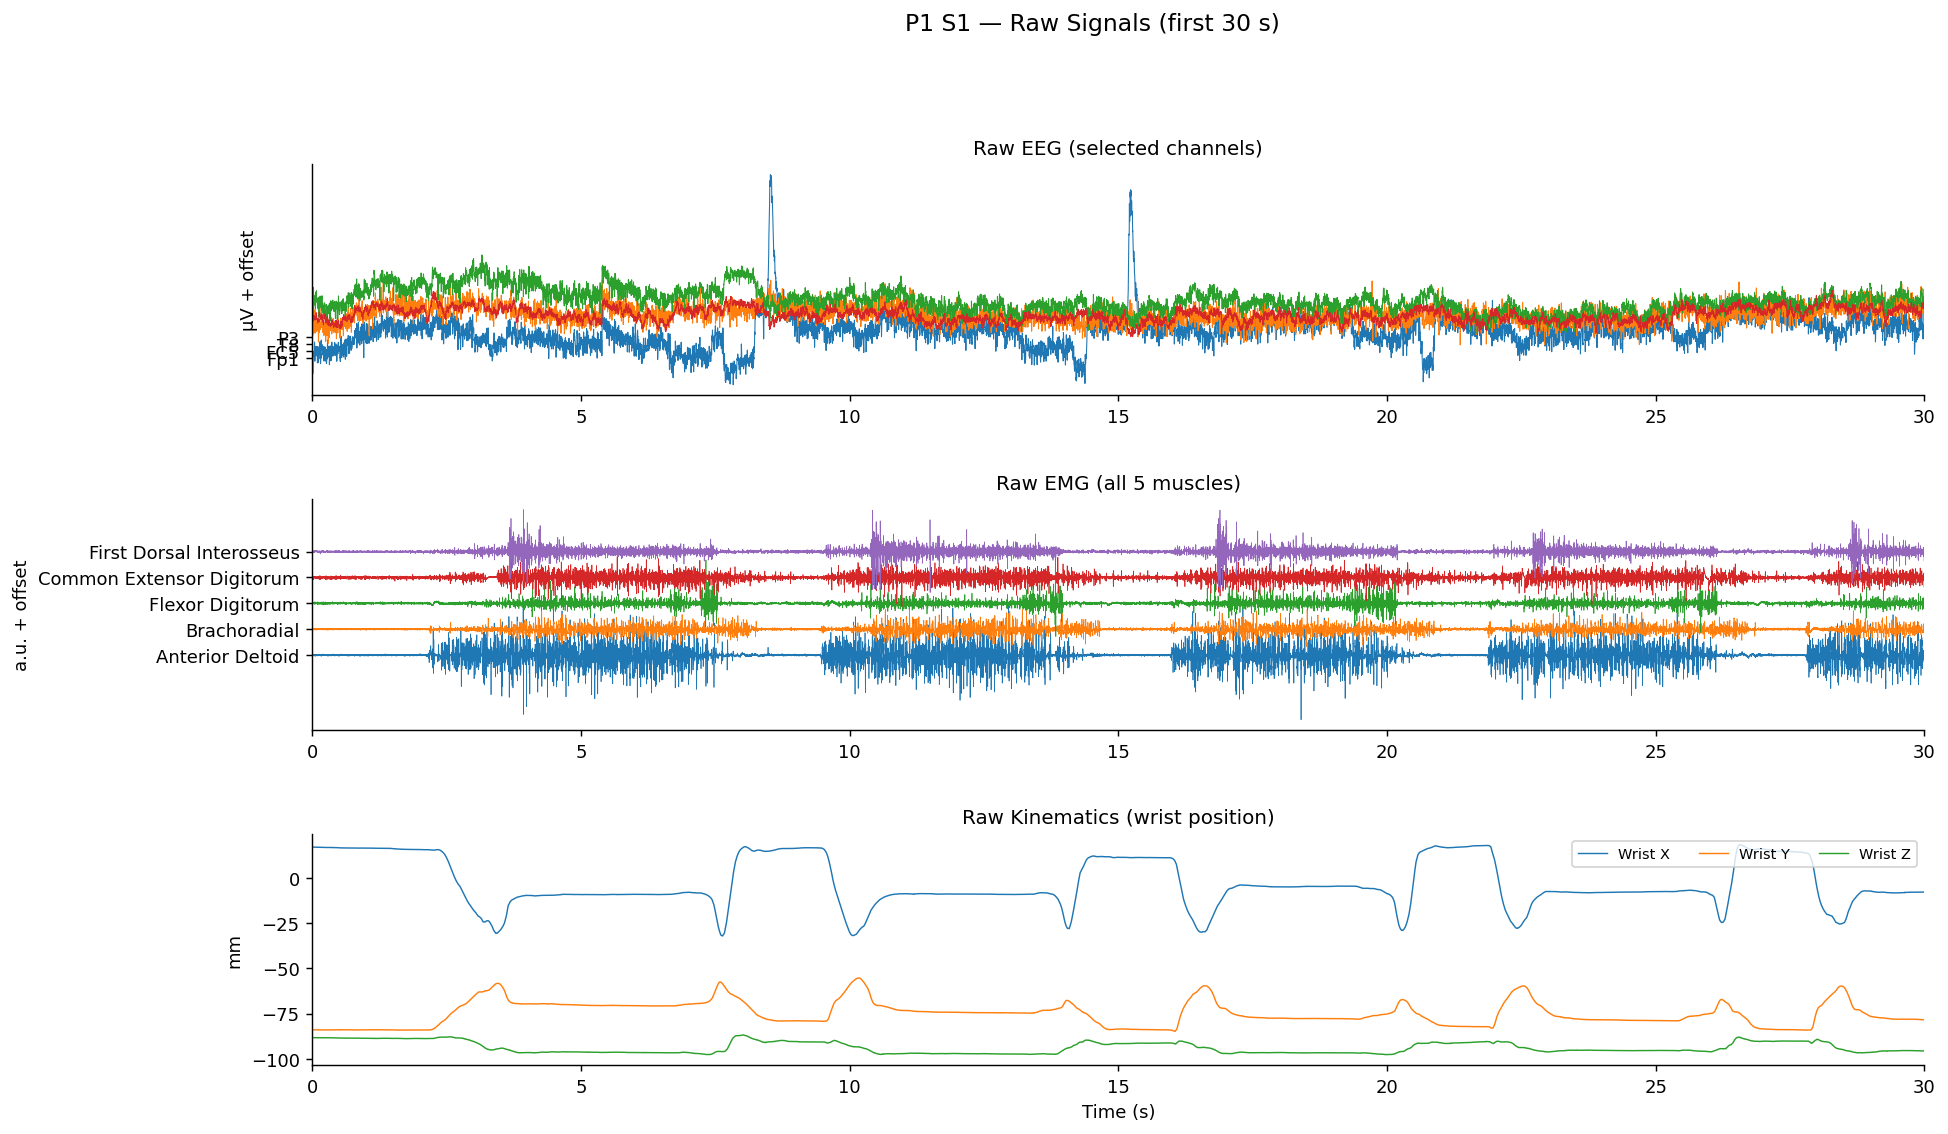

In [4]:
T_SHOW = int(30 * FS_EEG)   # 30 s at EEG rate
t_eeg  = np.arange(T_SHOW) / FS_EEG
t_emg  = np.arange(int(30 * FS_EMG)) / FS_EMG
t_kin  = t_eeg

EEG_CHANS  = [0, 7, 15, 23]   # representative channels
EMG_CHANS  = list(range(5))
KIN_COLS   = [9, 10, 11]       # wrist X, Y, Z

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# — EEG panel
ax0 = fig.add_subplot(gs[0])
eeg_raw = raw['eeg'][:T_SHOW]
offsets = np.arange(len(EEG_CHANS)) * 120
for i, ch in enumerate(EEG_CHANS):
    ax0.plot(t_eeg, eeg_raw[:, ch] + offsets[i], lw=0.6,
             label=raw['eeg_names'][ch])
ax0.set_title('Raw EEG (selected channels)')
ax0.set_ylabel('µV + offset')
ax0.set_yticks(offsets)
ax0.set_yticklabels([raw['eeg_names'][c] for c in EEG_CHANS])
ax0.set_xlim(0, 30)

# — EMG panel
ax1 = fig.add_subplot(gs[1])
emg_raw = raw['emg'][:int(30 * FS_EMG)]
t_emg_30 = np.arange(len(emg_raw)) / FS_EMG
emg_off = np.arange(5) * (np.abs(emg_raw).max() * 0.4 + 1e-3)
for i in range(5):
    ax1.plot(t_emg_30, emg_raw[:, i] + emg_off[i], lw=0.4,
             label=raw['emg_names'][i])
ax1.set_title('Raw EMG (all 5 muscles)')
ax1.set_ylabel('a.u. + offset')
ax1.set_yticks(emg_off)
ax1.set_yticklabels(raw['emg_names'])
ax1.set_xlim(0, 30)

# — Kinematics panel
ax2 = fig.add_subplot(gs[2])
kin_raw = raw['kin'][:T_SHOW]
kin_labels = ['Wrist X', 'Wrist Y', 'Wrist Z']
for i, col in enumerate(KIN_COLS):
    ax2.plot(t_kin, kin_raw[:, col], lw=0.8, label=kin_labels[i])
ax2.set_title('Raw Kinematics (wrist position)')
ax2.set_ylabel('mm')
ax2.set_xlabel('Time (s)')
ax2.set_xlim(0, 30)
ax2.legend(loc='upper right', fontsize=8, ncol=3)

fig.suptitle(f'P{PARTICIPANT} S{SERIES} — Raw Signals (first 30 s)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 2 · EEG Preprocessing

Pipeline: **BP 0.1–40 Hz → Notch 50 Hz → ASR → CAR → Delta 0.1–2 Hz**

In [5]:
eeg_raw = raw['eeg']
fs      = float(raw['fs_eeg'])

eeg_bp    = bandpass(eeg_raw, fs)
eeg_notch = notch(eeg_bp, fs)
eeg_asr   = asr(eeg_notch, fs)
eeg_car   = common_average_reference(eeg_asr)
eeg_delta = delta_band(eeg_car, fs)

stages = [
    ('Raw',         eeg_raw),
    ('BP 0.1–40 Hz', eeg_bp),
    ('Notch 50 Hz', eeg_notch),
    ('ASR',         eeg_asr),
    ('CAR',         eeg_car),
    ('Delta 0.1–2 Hz', eeg_delta),
]

print('EEG preprocessing stages done.')
for name, arr in stages:
    print(f'  {name:18s}: {arr.shape}  std={arr.std():.3f} µV')

EEG preprocessing stages done.
  Raw               : (119496, 32)  std=433.284 µV
  BP 0.1–40 Hz      : (119496, 32)  std=142.664 µV
  Notch 50 Hz       : (119496, 32)  std=142.634 µV
  ASR               : (119496, 32)  std=140.198 µV
  CAR               : (119496, 32)  std=120.417 µV
  Delta 0.1–2 Hz    : (119496, 32)  std=98.426 µV


## Figure 2: EEG pipeline stage-by-stage (one channel, 10 s)

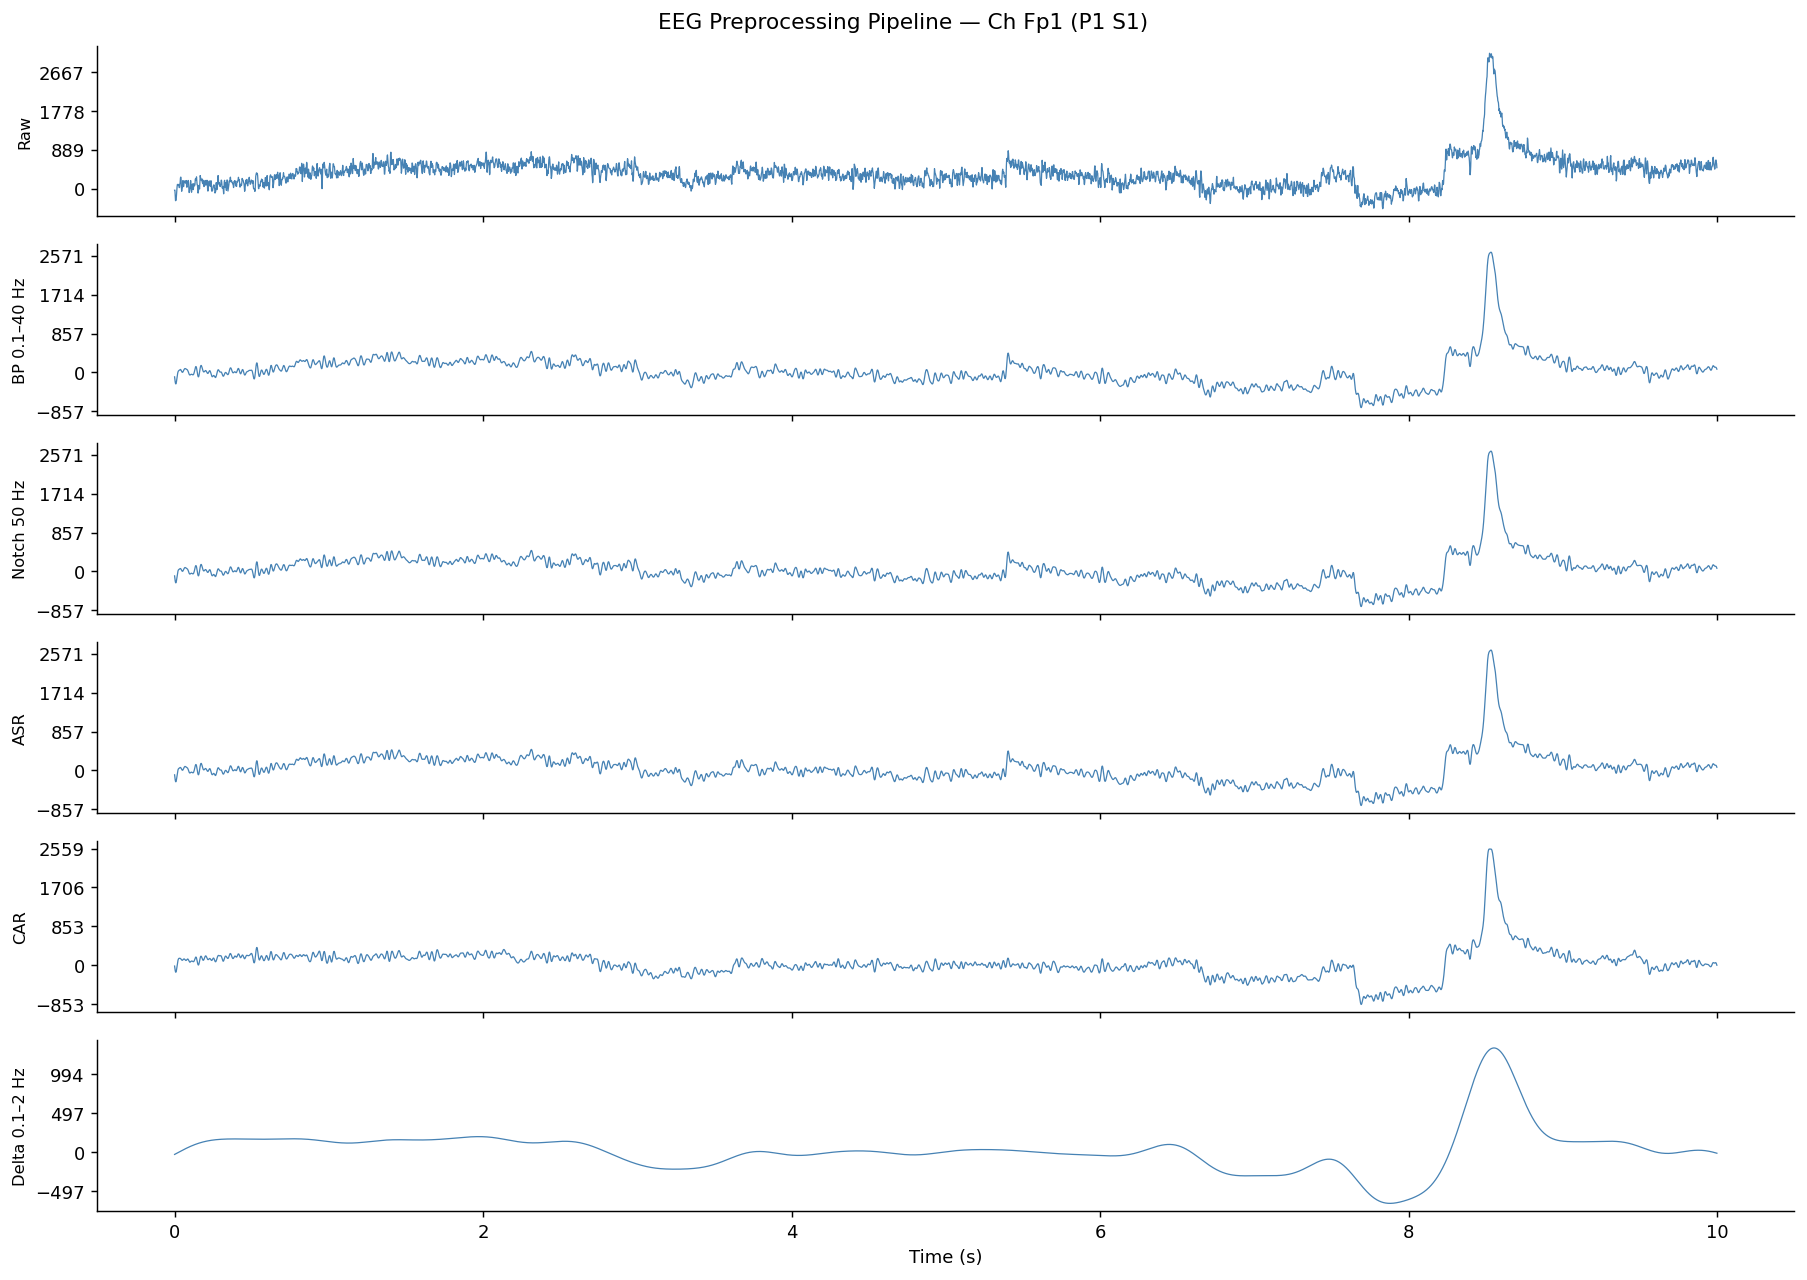

In [6]:
CH   = 0          # Fp1 or first channel
WIN  = int(10 * fs)
t10  = np.arange(WIN) / fs

fig, axes = plt.subplots(len(stages), 1, figsize=(14, 10), sharex=True)
for ax, (name, arr) in zip(axes, stages):
    ax.plot(t10, arr[:WIN, CH], lw=0.7, color='steelblue')
    ax.set_ylabel(name, fontsize=9)
    # Updated to use np.ptp() for NumPy 2.0 compatibility
    ax.yaxis.set_major_locator(MultipleLocator(max(1, round(np.ptp(arr[:WIN, CH]) / 4, 0))))

axes[-1].set_xlabel('Time (s)')
fig.suptitle(
    f'EEG Preprocessing Pipeline — Ch {raw["eeg_names"][CH]} (P{PARTICIPANT} S{SERIES})',
    fontsize=12)
plt.tight_layout()
plt.show()

## Figure 3: Power Spectral Density at each stage

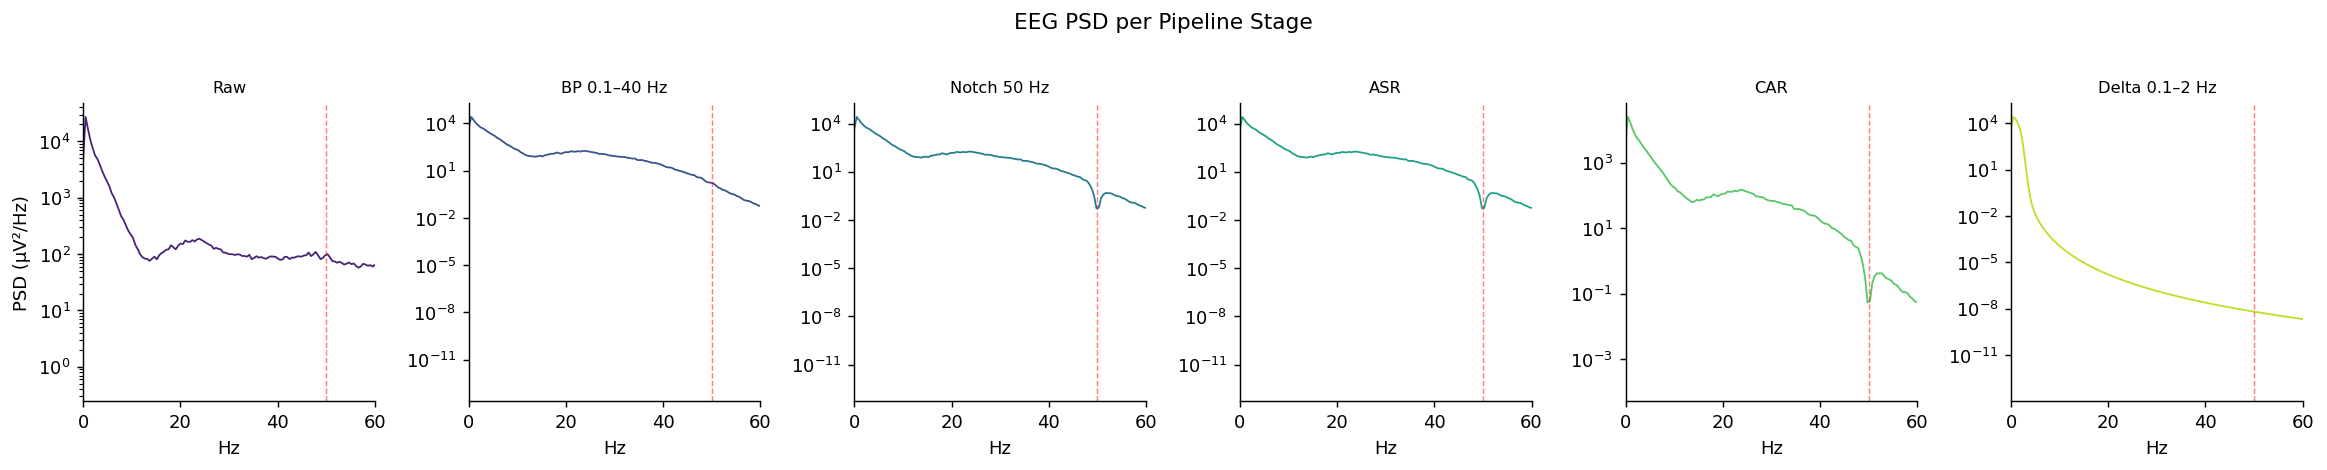

In [7]:
fig, axes = plt.subplots(1, len(stages), figsize=(18, 3.5), sharey=False)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(stages)))

for ax, (name, arr), color in zip(axes, stages, colors):
    f, pxx = welch(arr[:, CH], fs=fs, nperseg=1024)
    ax.semilogy(f, pxx, lw=1.0, color=color)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Hz')
    ax.set_xlim(0, 60)
    ax.axvline(50, color='red', lw=0.8, ls='--', alpha=0.5)   # power line

axes[0].set_ylabel('PSD (µV²/Hz)')
fig.suptitle('EEG PSD per Pipeline Stage', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Figure 4: All 32 channels after full pipeline (butterfly + mean)

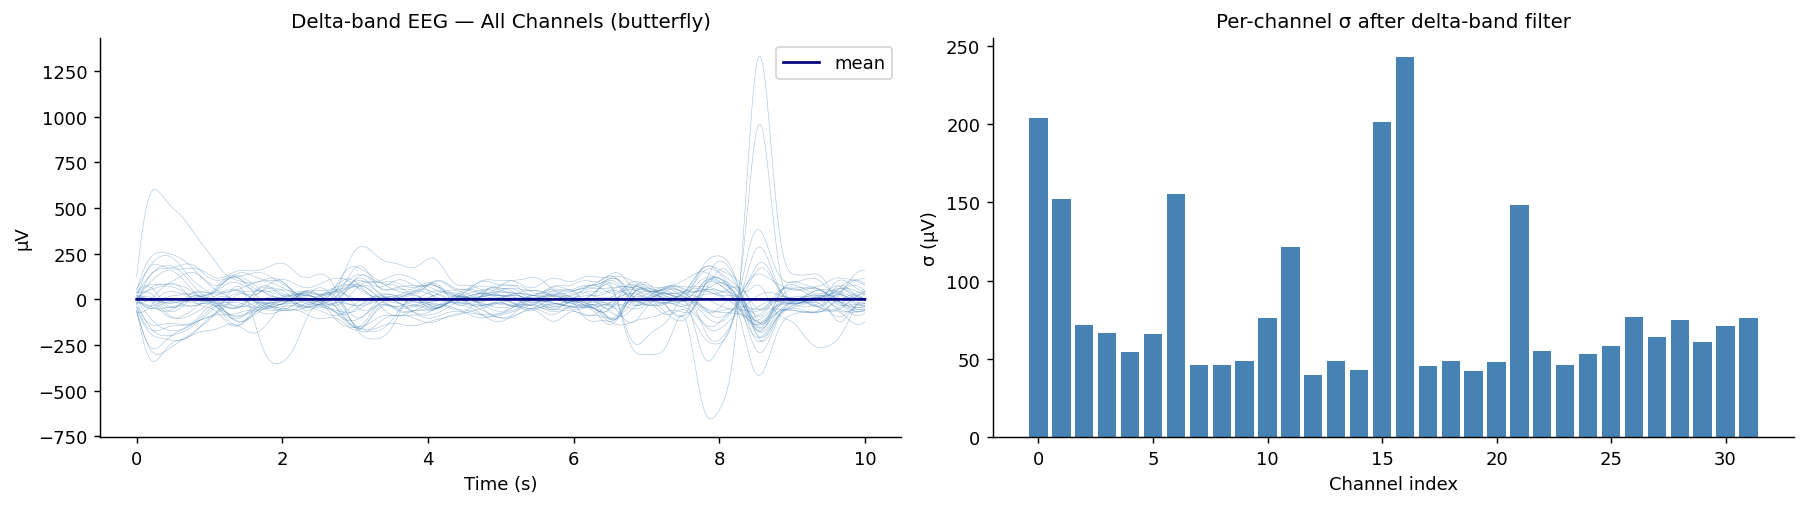

In [8]:
WIN = int(10 * fs)
t10 = np.arange(WIN) / fs

fig, (ax_fly, ax_std) = plt.subplots(1, 2, figsize=(14, 4))

# Butterfly
for ch in range(eeg_delta.shape[1]):
    ax_fly.plot(t10, eeg_delta[:WIN, ch], lw=0.3, alpha=0.5, color='steelblue')
ax_fly.plot(t10, eeg_delta[:WIN].mean(axis=1), lw=1.5, color='navy', label='mean')
ax_fly.set_title('Delta-band EEG — All Channels (butterfly)')
ax_fly.set_xlabel('Time (s)')
ax_fly.set_ylabel('µV')
ax_fly.legend()

# Per-channel std bar
ch_std = eeg_delta.std(axis=0)
ax_std.bar(range(32), ch_std, color='steelblue', edgecolor='none')
ax_std.set_title('Per-channel σ after delta-band filter')
ax_std.set_xlabel('Channel index')
ax_std.set_ylabel('σ (µV)')

plt.tight_layout()
plt.show()

---
## 3 · EMG Preprocessing

Pipeline: **BP 30–300 Hz → |·| rectify → LP 10 Hz envelope → Decimate ×8 (4000→500 Hz)**

In [9]:
emg_raw  = raw['emg']
fs_emg   = float(raw['fs_emg'])

emg_bp   = emg_bandpass(emg_raw, fs_emg)
emg_rect = rectify(emg_bp)
emg_lp   = lowpass_envelope(emg_rect, fs_emg)
emg_dec  = downsample(emg_lp, factor=8)

emg_stages = [
    ('Raw',          emg_raw,  fs_emg),
    ('BP 30–300 Hz', emg_bp,   fs_emg),
    ('Rectified',    emg_rect, fs_emg),
    ('LP 10 Hz',     emg_lp,   fs_emg),
    ('Decimated ×8', emg_dec,  fs_emg / 8),
]

print('EMG preprocessing stages done.')
for name, arr, fs_s in emg_stages:
    print(f'  {name:18s}: {arr.shape}  @ {int(fs_s)} Hz  std={arr.std():.4f}')

EMG preprocessing stages done.
  Raw               : (955969, 5)  @ 4000 Hz  std=0.0883
  BP 30–300 Hz      : (955969, 5)  @ 4000 Hz  std=0.0799
  Rectified         : (955969, 5)  @ 4000 Hz  std=0.0688
  LP 10 Hz          : (955969, 5)  @ 4000 Hz  std=0.0435
  Decimated ×8      : (119497, 5)  @ 500 Hz  std=0.0430


## Figure 5: EMG pipeline stage-by-stage (one muscle, 10 s)

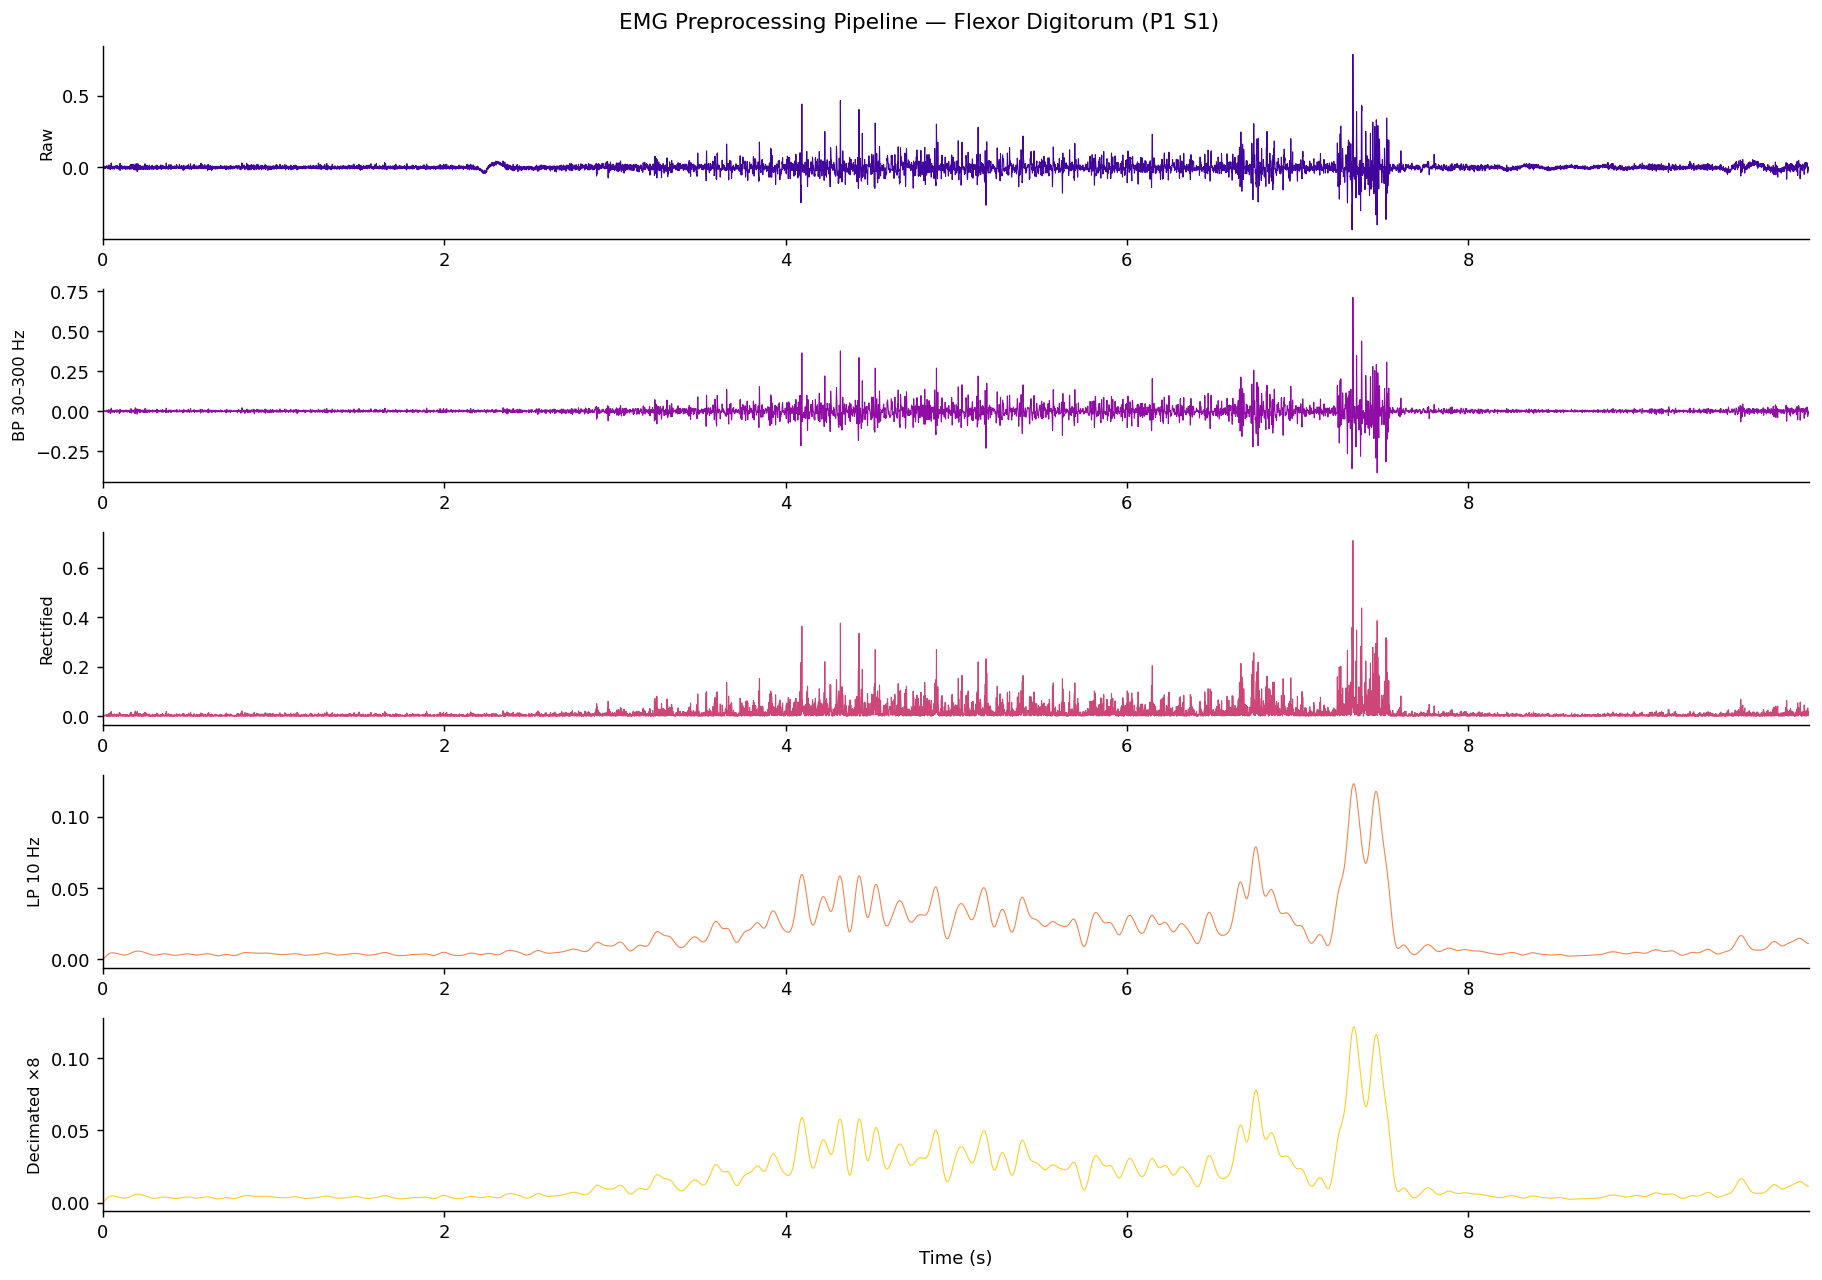

In [10]:
MUSCLE = 2   # FD — Flexor Digitorum (most active during grasp)

fig, axes = plt.subplots(len(emg_stages), 1, figsize=(14, 10), sharex=False)
colors_emg = plt.cm.plasma(np.linspace(0.1, 0.9, len(emg_stages)))

for ax, (name, arr, fs_s), color in zip(axes, emg_stages, colors_emg):
    n = min(int(10 * fs_s), arr.shape[0])
    t = np.arange(n) / fs_s
    ax.plot(t, arr[:n, MUSCLE], lw=0.6, color=color)
    ax.set_ylabel(name, fontsize=9)
    ax.set_xlim(0, t[-1])

axes[-1].set_xlabel('Time (s)')
fig.suptitle(
    f'EMG Preprocessing Pipeline — {raw["emg_names"][MUSCLE]} (P{PARTICIPANT} S{SERIES})',
    fontsize=12)
plt.tight_layout()
plt.show()

## Figure 6: All 5 EMG envelope channels overlaid (after decimate)

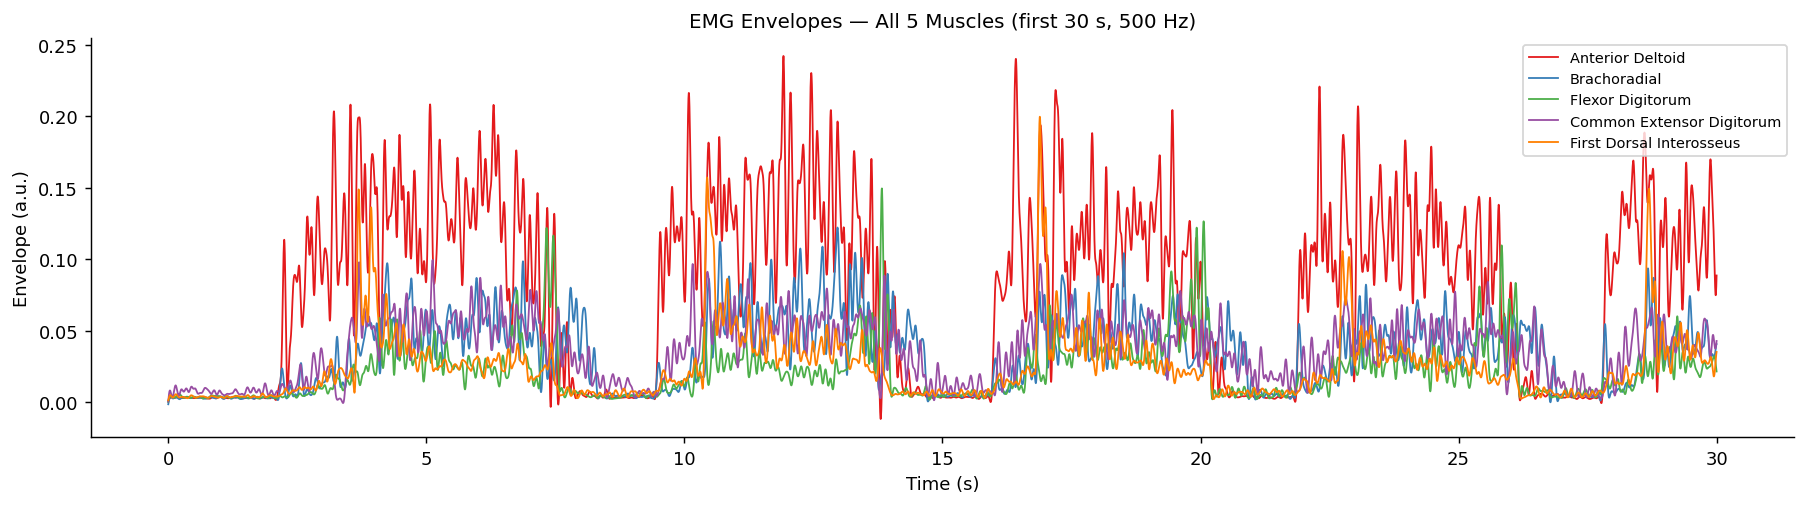

In [11]:
EMG_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
n_dec = min(int(30 * (fs_emg / 8)), emg_dec.shape[0])
t_dec = np.arange(n_dec) / (fs_emg / 8)

fig, ax = plt.subplots(figsize=(14, 4))
for i in range(5):
    ax.plot(t_dec, emg_dec[:n_dec, i], lw=1.0,
            color=EMG_COLORS[i], label=raw['emg_names'][i])
ax.set_title('EMG Envelopes — All 5 Muscles (first 30 s, 500 Hz)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Envelope (a.u.)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# Figure 7: EMG PSD before and after bandpass

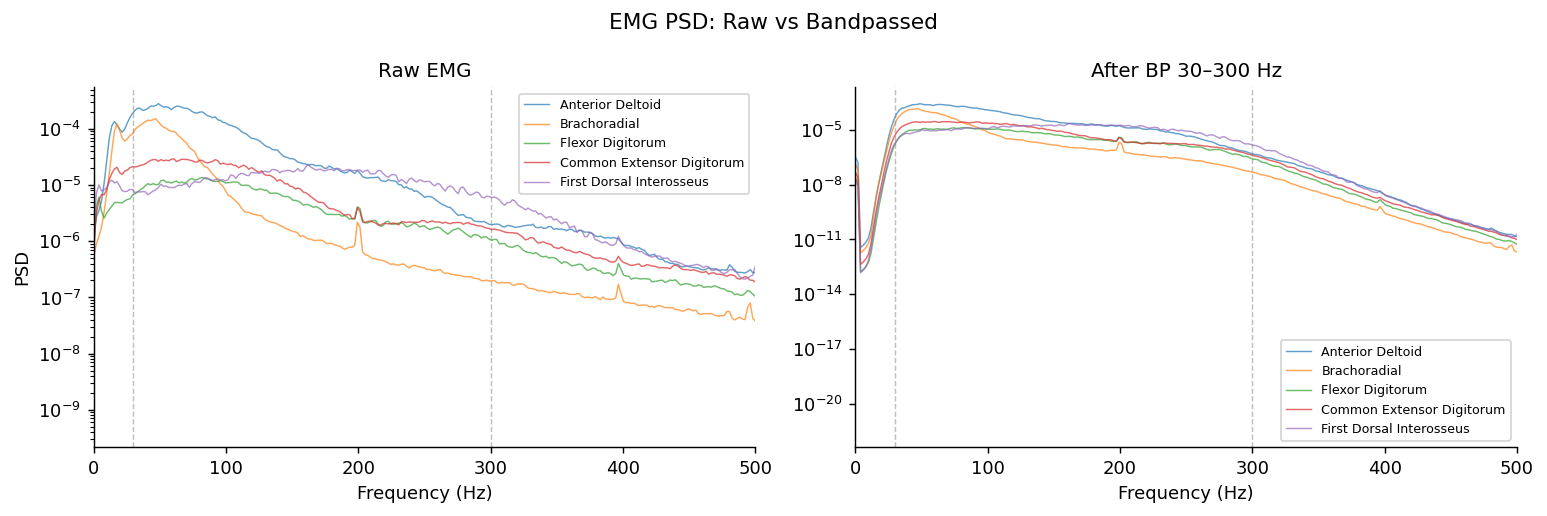

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (arr, fs_s, title) in zip(axes, [
    (emg_raw, fs_emg, 'Raw EMG'),
    (emg_bp,  fs_emg, 'After BP 30–300 Hz'),
]):
    for i in range(5):
        f, p = welch(arr[:, i], fs=fs_s, nperseg=2048)
        ax.semilogy(f, p, lw=0.8, alpha=0.7, label=raw['emg_names'][i])
    ax.set_title(title)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, 500)
    ax.axvline(30,  color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.axvline(300, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.legend(fontsize=7)

axes[0].set_ylabel('PSD')
fig.suptitle('EMG PSD: Raw vs Bandpassed', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4 · Kinematics Preprocessing

Build **k_t (13-dim)**: wrist(3), index(3), thumb(3), grip-distance(1), F_L(1), F_G(1), ρ_GL(1)  
Optional velocity via **Savitzky-Golay** or **Butterworth differentiator**

In [13]:
kin_raw = raw['kin']
kt      = extract_kt_raw(kin_raw)   # (T, 13)

KT_LABELS = [
    'Wrist X', 'Wrist Y', 'Wrist Z',
    'Index X', 'Index Y', 'Index Z',
    'Thumb X', 'Thumb Y', 'Thumb Z',
    'd_grip',  'F_L',     'F_G',     'ρ_GL',
]

print(f'k_t shape: {kt.shape}   (T, 13)')
print(f'k_t stats  mean: {kt.mean(axis=0).round(3)}')
print(f'           std : {kt.std(axis=0).round(3)}')

k_t shape: (119496, 13)   (T, 13)
k_t stats  mean: [-4.1030002e+00 -7.5456001e+01 -9.3620003e+01 -1.1679000e+01
  1.0391700e+02 -7.7682999e+01  1.0070000e+02 -1.2082100e+02
  4.6245998e+01  2.8050101e+02  9.5400000e-01  1.0600000e-01
  2.4828232e+04]
           std : [1.3864000e+01 7.0040002e+00 3.1550000e+00 3.5880001e+00 7.1910000e+00
 5.6149998e+00 6.7440000e+00 4.5009999e+00 7.0060000e+00 4.0060000e+00
 1.2100000e+00 1.4300001e-01 1.8393817e+05]


## Figure 8: All 13 k_t features (30 s)

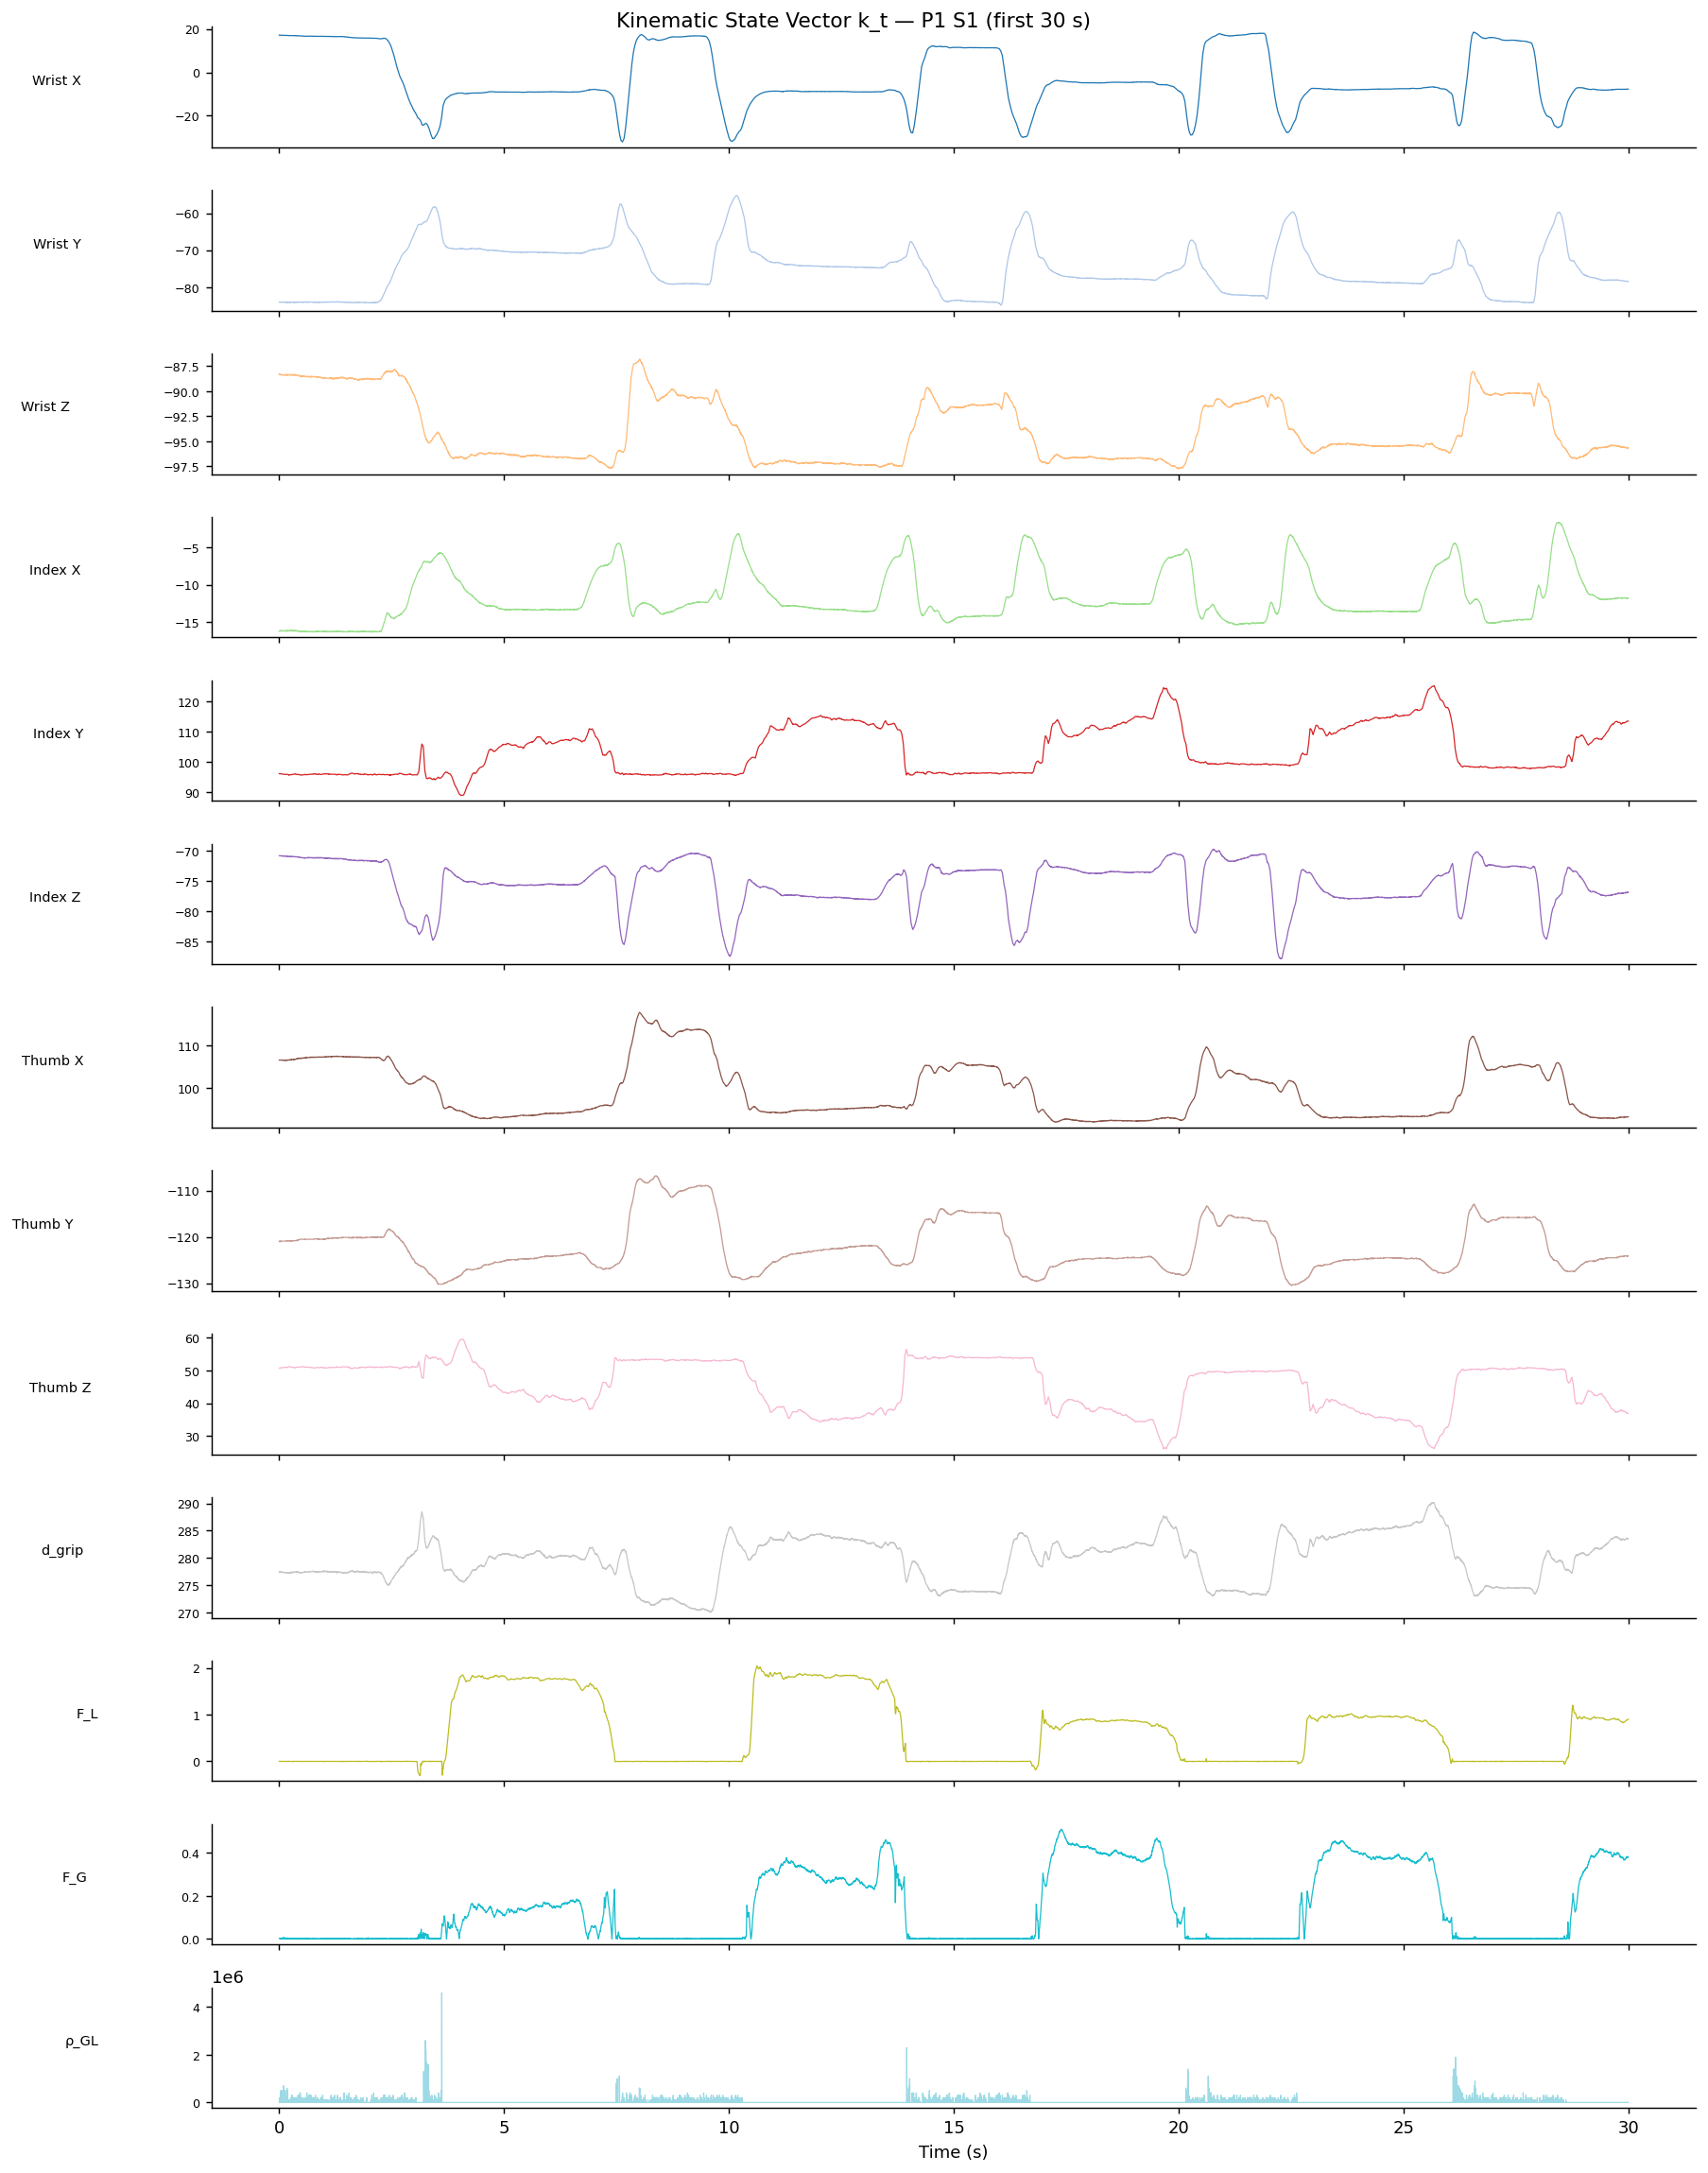

In [14]:
n_kin = min(int(30 * FS_KIN), kt.shape[0])
t_kin = np.arange(n_kin) / FS_KIN

fig, axes = plt.subplots(13, 1, figsize=(14, 18), sharex=True)
colors_k = plt.cm.tab20(np.linspace(0, 1, 13))

for i, (ax, label, color) in enumerate(zip(axes, KT_LABELS, colors_k)):
    ax.plot(t_kin, kt[:n_kin, i], lw=0.7, color=color)
    ax.set_ylabel(label, fontsize=8, rotation=0, ha='right', labelpad=55)
    ax.yaxis.set_tick_params(labelsize=7)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Kinematic State Vector k_t — P{PARTICIPANT} S{SERIES} (first 30 s)', fontsize=12)
plt.tight_layout()
plt.show()

## Figure 9: Velocity comparison SG vs Butterworth (wrist X, Y, Z)

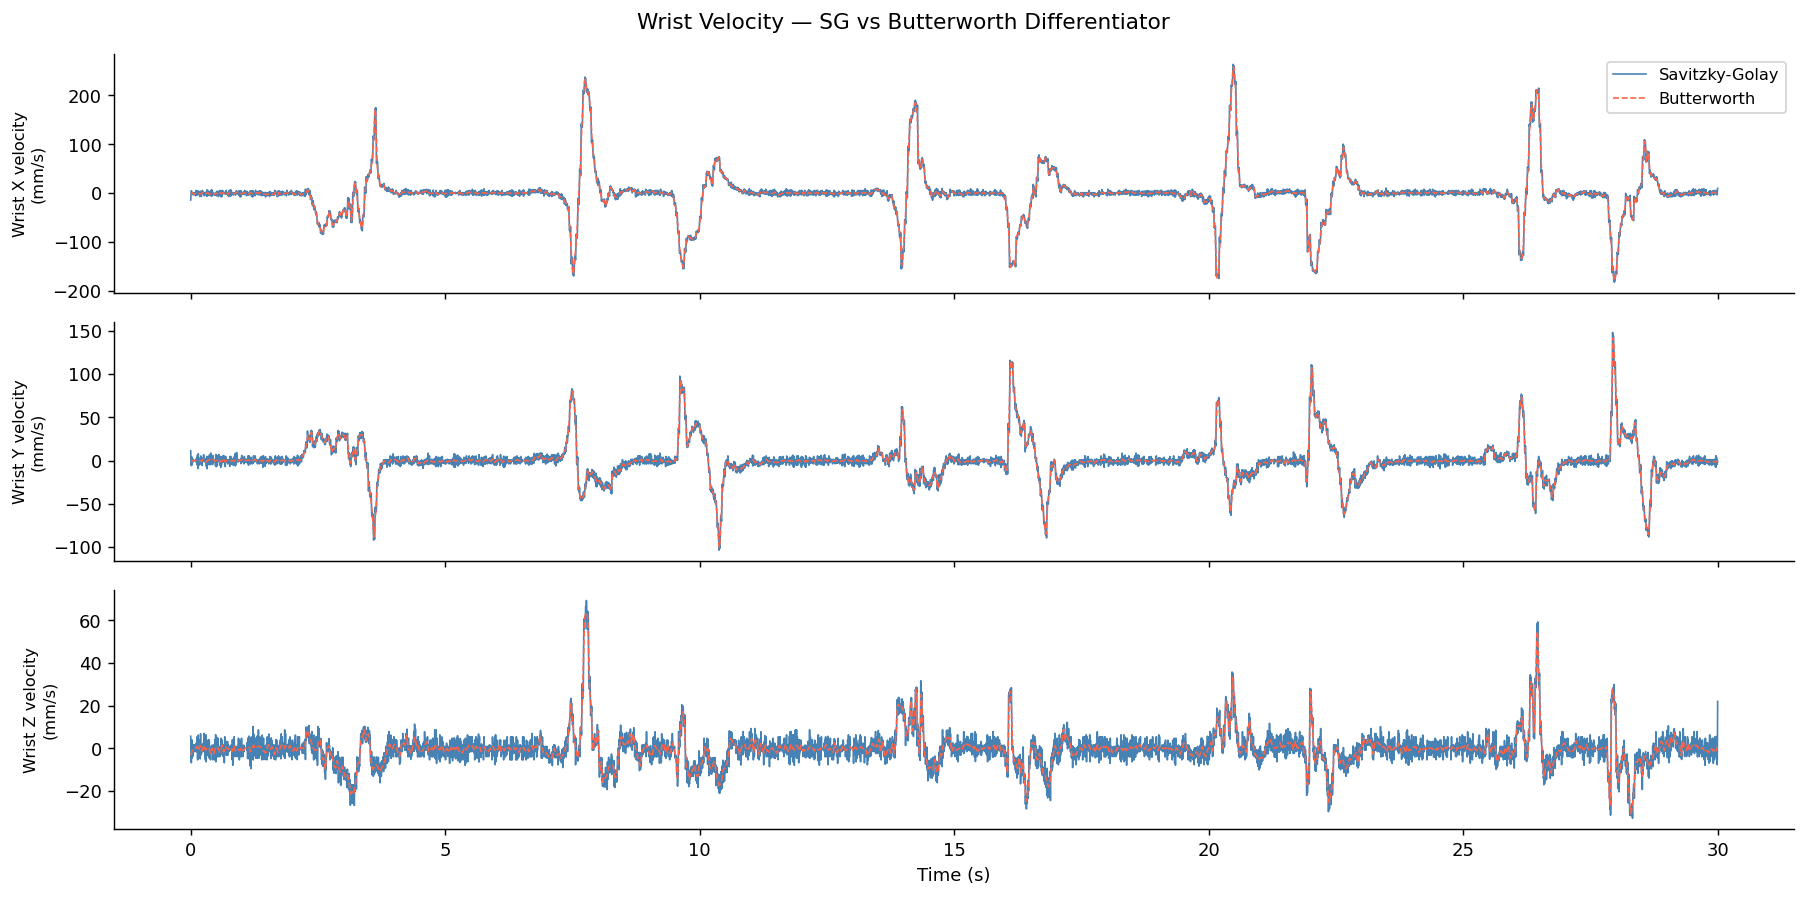

In [15]:
pos_cols = kt[:n_kin, :3]   # wrist X, Y, Z

vel_sg = sg_velocity(pos_cols, fs=float(FS_KIN), window=11, poly=3)
vel_bw = bw_velocity(pos_cols, fs=float(FS_KIN), cutoff=20.0, order=4)

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
axis_labels = ['Wrist X', 'Wrist Y', 'Wrist Z']

for i, (ax, lbl) in enumerate(zip(axes, axis_labels)):
    ax.plot(t_kin, vel_sg[:, i], lw=0.9, color='steelblue',  label='Savitzky-Golay')
    ax.plot(t_kin, vel_bw[:, i], lw=0.9, color='tomato', ls='--', label='Butterworth')
    ax.set_ylabel(f'{lbl} velocity\n(mm/s)', fontsize=9)
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Wrist Velocity — SG vs Butterworth Differentiator', fontsize=12)
plt.tight_layout()
plt.show()

## Figure 10: k_t correlation heatmap

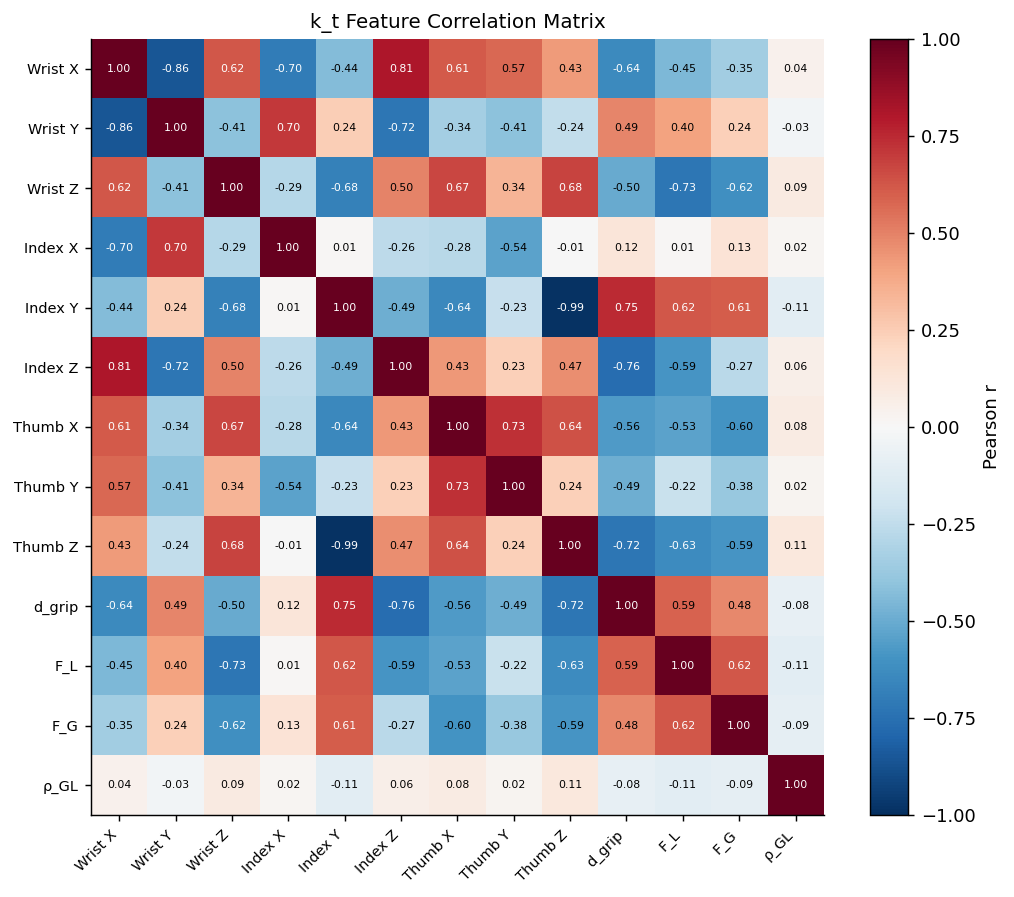

In [16]:
corr = np.corrcoef(kt.T)   # (13, 13)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(13)); ax.set_yticks(range(13))
ax.set_xticklabels(KT_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(KT_LABELS, fontsize=8)

# Annotate
for i in range(13):
    for j in range(13):
        val = corr[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('k_t Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# 5.CCA Alignment (EEG 32 → 13 canonical components)

In [19]:
# Align lengths
T_min = min(eeg_delta.shape[0], kt.shape[0])
eeg_aligned = eeg_delta[:T_min]
kt_aligned  = kt[:T_min]
# Use first 70% as 'train' for CCA fit (mimics train split)
T_train = int(0.7 * T_min)
N_CCA = cfg['preprocessing']['cca']['n_components']   # 13 from config
cca = EEGKinCCA(n_components=N_CCA)
cca.fit([eeg_aligned[:T_train]], [kt_aligned[:T_train]])
eeg_cca = cca.transform(eeg_aligned)   # (T_min, 13)
print(f'Input  EEG : {eeg_aligned.shape}   (T, 32)')
print(f'Output CCA : {eeg_cca.shape}   (T, {N_CCA})')
print(f'CCA scores std per component: {eeg_cca.std(axis=0).round(4)}')

Input  EEG : (119496, 32)   (T, 32)
Output CCA : (119496, 13)   (T, 13)
CCA scores std per component: [0.     0.2413 0.3111 0.3342 0.3738 0.3465 0.3064 0.2119 0.3716 0.3387
 0.3707 0.3533 0.3563]


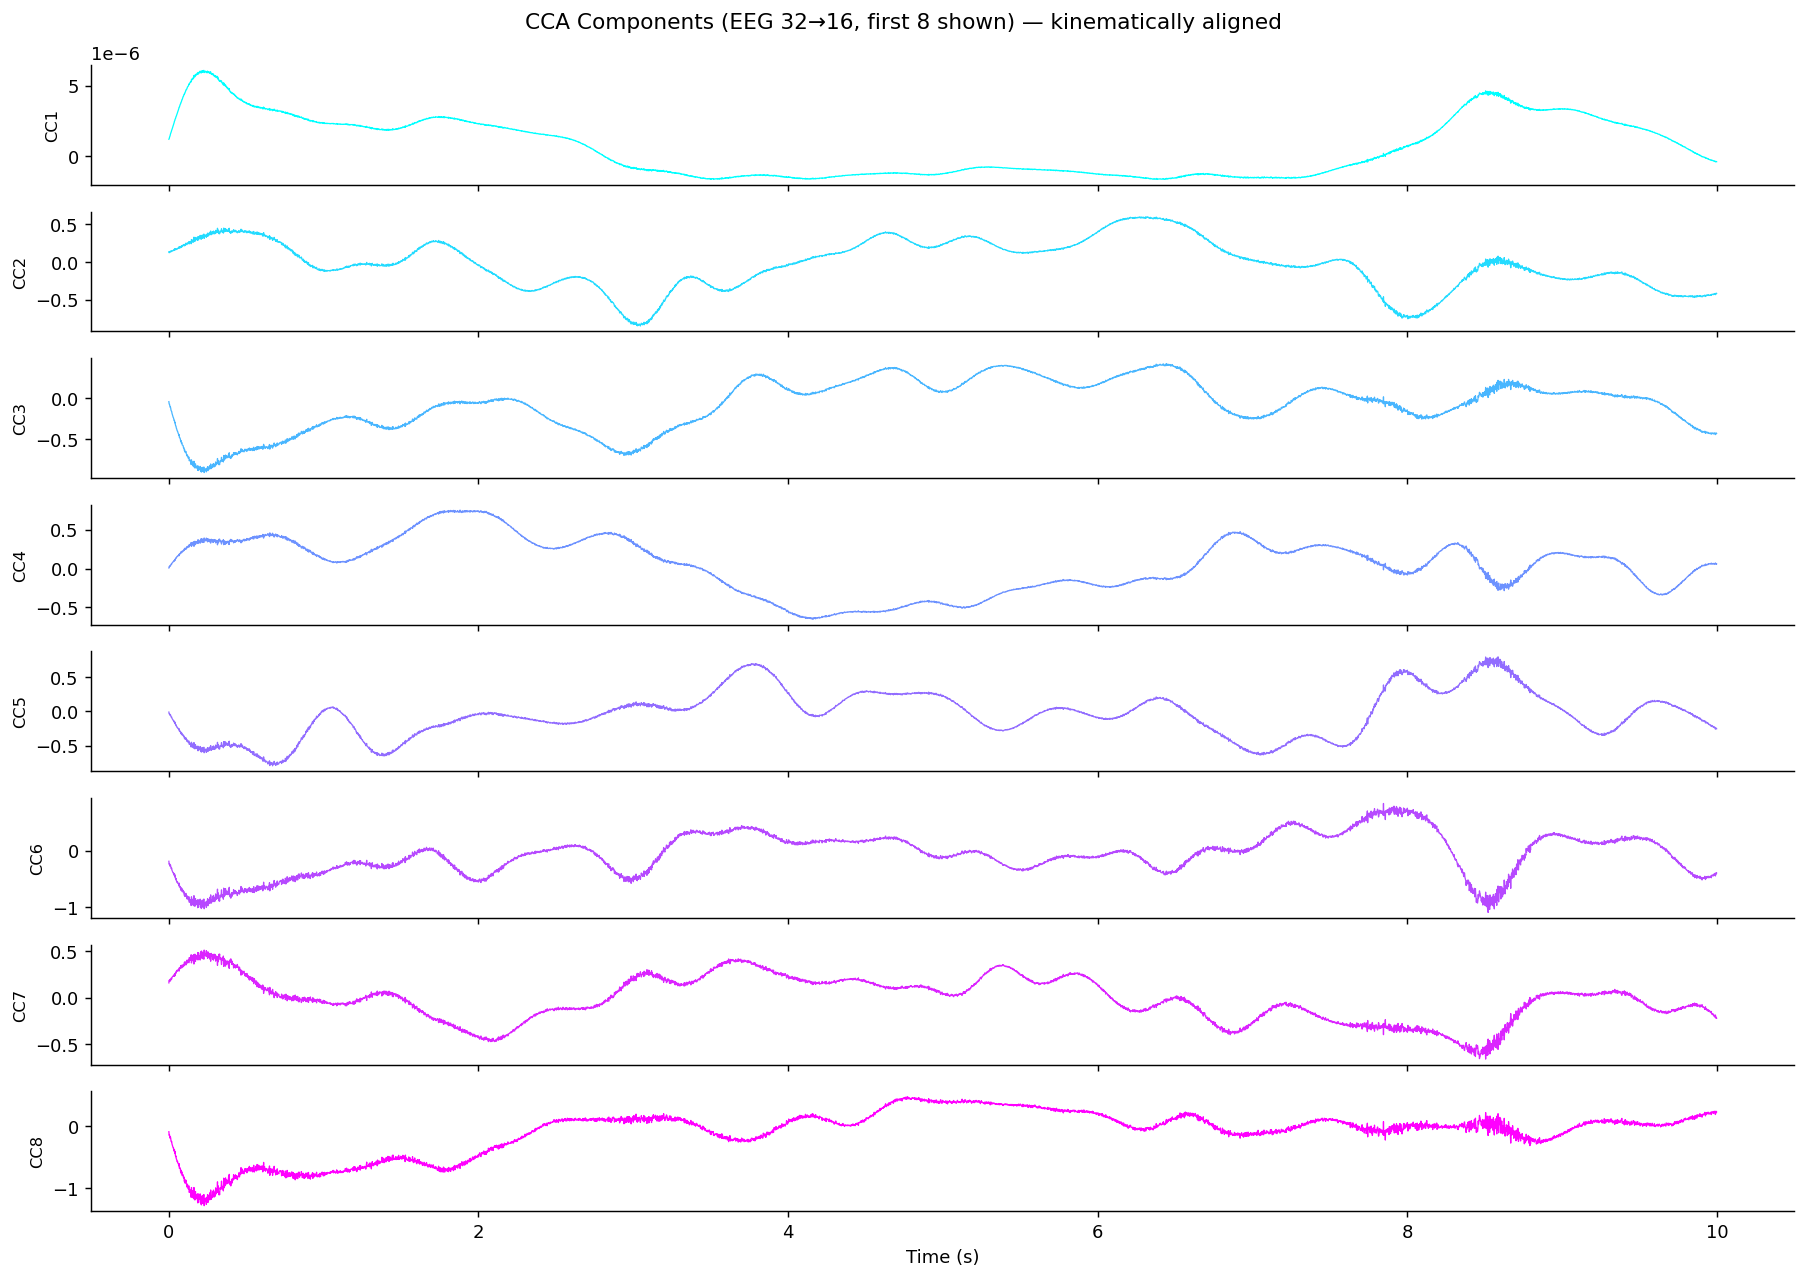

In [22]:
N_COMP_SHOW = 8
n_cca = min(int(10 * FS_EEG), eeg_cca.shape[0])
t_cca = np.arange(n_cca) / FS_EEG

fig, axes = plt.subplots(N_COMP_SHOW, 1, figsize=(14, 10), sharex=True)
comp_colors = plt.cm.cool(np.linspace(0, 1, N_COMP_SHOW))

for i, (ax, color) in enumerate(zip(axes, comp_colors)):
    ax.plot(t_cca, eeg_cca[:n_cca, i], lw=0.7, color=color)
    ax.set_ylabel(f'CC{i+1}', fontsize=9)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('CCA Components (EEG 32→16, first 8 shown) — kinematically aligned', fontsize=12)
plt.tight_layout()
plt.show()

## Figure 12: EEG–Kinematics correlation before vs after CCA

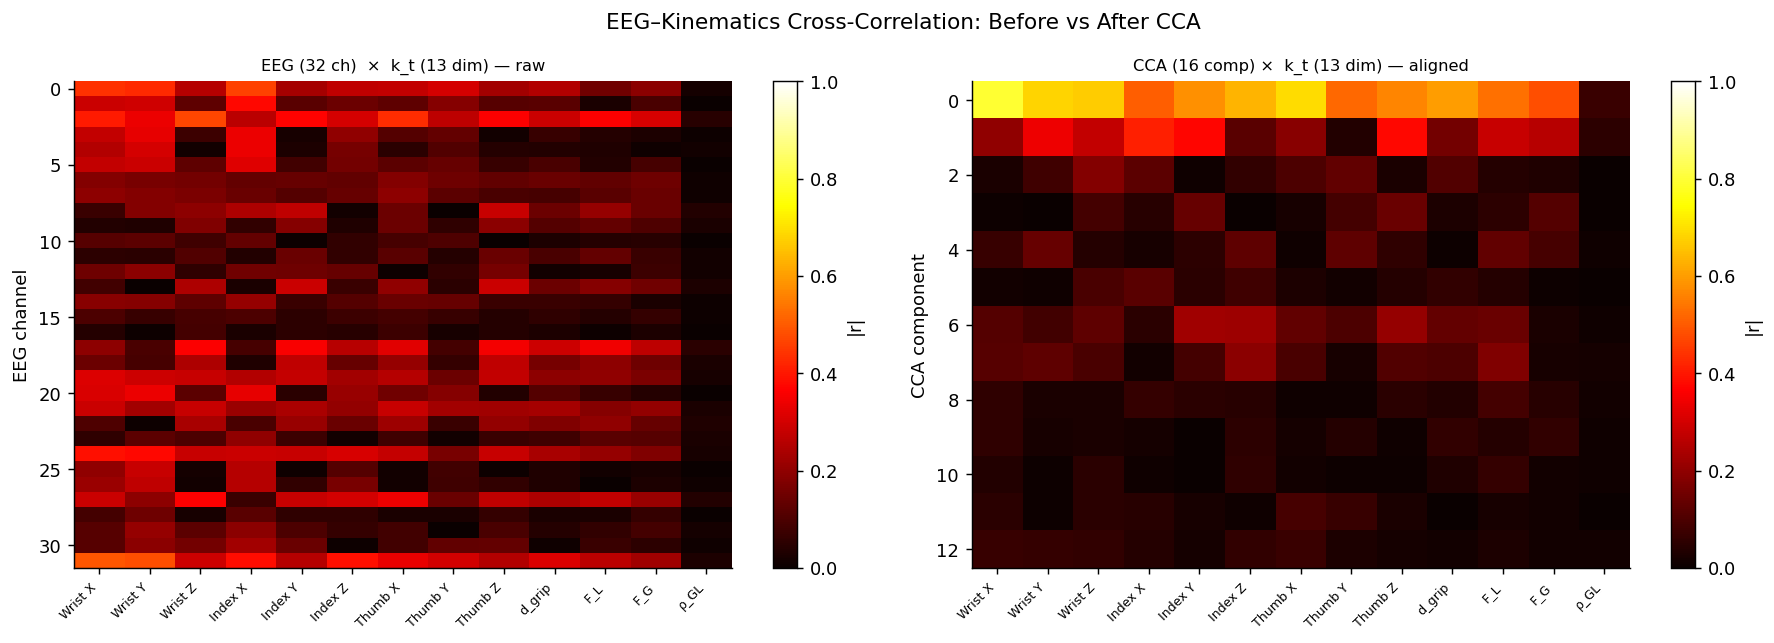

In [23]:
def cross_corr_matrix(A, B):
    """Pearson r between every column of A and every column of B."""
    A_n = (A - A.mean(0)) / (A.std(0) + 1e-8)
    B_n = (B - B.mean(0)) / (B.std(0) + 1e-8)
    return (A_n.T @ B_n) / A_n.shape[0]   # (C_A, C_B)

corr_before = cross_corr_matrix(eeg_aligned, kt_aligned)   # (32, 13)
corr_after  = cross_corr_matrix(eeg_cca,     kt_aligned)   # (16, 13)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr, title, ylabel in [
    (axes[0], corr_before, 'EEG (32 ch)  ×  k_t (13 dim) — raw', 'EEG channel'),
    (axes[1], corr_after,  'CCA (16 comp) ×  k_t (13 dim) — aligned', 'CCA component'),
]:
    im = ax.imshow(np.abs(corr), cmap='hot', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(13))
    ax.set_xticklabels(KT_LABELS, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, label='|r|')

fig.suptitle('EEG–Kinematics Cross-Correlation: Before vs After CCA', fontsize=12)
plt.tight_layout()
plt.show()

---
# 6 · Dataset & Windowing

In [28]:
from src.data.dataset import WAYEEGDataset, extract_kt
from src.preprocessing.eeg import preprocess_eeg_from_config
from src.preprocessing.emg import preprocess_emg_from_config

def make_preprocess_fn(cfg):
    """Build a series_dict -> series_dict transform for WAYEEGDataset.

    Only preprocesses EEG and EMG. Kinematics are left as raw 36-col so
    that dataset._index_series can call extract_kt() correctly.
    """
    def preprocess_fn(s):
        s = dict(s)
        s['eeg'] = preprocess_eeg_from_config(s['eeg'], float(s['fs_eeg']), cfg['preprocessing']['eeg'])
        s['emg'] = preprocess_emg_from_config(s['emg'], float(s['fs_emg']), cfg['preprocessing']['emg'])
        # kin: leave as raw (T, 36) — dataset.py calls extract_kt() internally
        return s
    return preprocess_fn

preprocess_fn = make_preprocess_fn(cfg)

ds = WAYEEGDataset(
    data_dir=DATA_DIR,
    participants=[PARTICIPANT],
    split='train',
    window_size=cfg['data']['window_size'],
    stride=cfg['data']['stride'],
    preprocess_fn=preprocess_fn,
)

print(ds)
print(f'Windows: {len(ds)}')
eeg_w, kin_w, emg_w = ds[0]
print(f'Sample shapes — EEG: {tuple(eeg_w.shape)}  KIN: {tuple(kin_w.shape)}  EMG: {tuple(emg_w.shape)}')

WAYEEGDataset(split='train', participants=[1], n_windows=26035, window_size=500, stride=50)
Windows: 26035
Sample shapes — EEG: (500, 32)  KIN: (500, 13)  EMG: (500, 5)


## Figure 13: One window — EEG / kin / EMG aligned in time

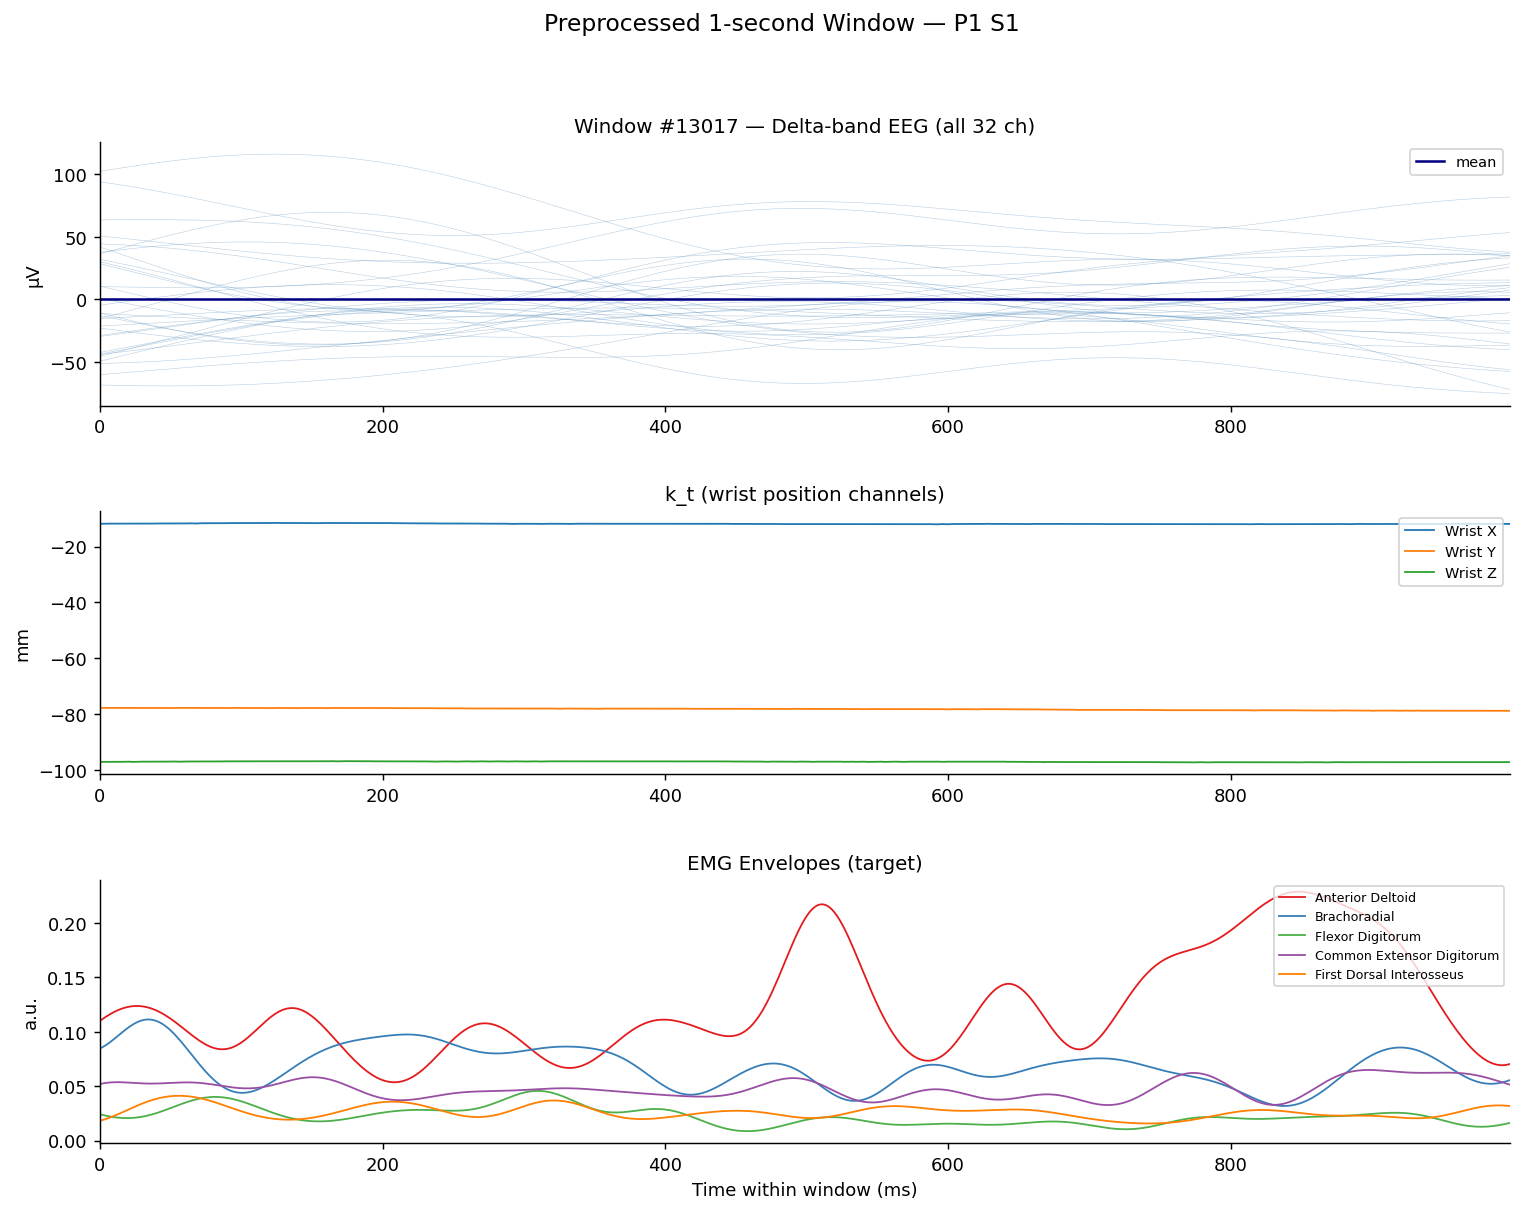

In [29]:
WIN_IDX = len(ds) // 2   # pick a mid-series window
eeg_w, kin_w, emg_w = ds[WIN_IDX]

eeg_np = eeg_w.numpy()   # (500, 32)
kin_np = kin_w.numpy()   # (500, 13)
emg_np = emg_w.numpy()   # (500, 5)

T_win   = eeg_np.shape[0]
t_win   = np.arange(T_win) / FS_EEG * 1000   # ms

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# EEG butterfly
ax0 = fig.add_subplot(gs[0])
for ch in range(eeg_np.shape[1]):
    ax0.plot(t_win, eeg_np[:, ch], lw=0.3, alpha=0.4, color='steelblue')
ax0.plot(t_win, eeg_np.mean(axis=1), lw=1.4, color='navy', label='mean')
ax0.set_title(f'Window #{WIN_IDX} — Delta-band EEG (all 32 ch)')
ax0.set_ylabel('µV')
ax0.legend(fontsize=8)

# Kinematics
ax1 = fig.add_subplot(gs[1])
for i, label in enumerate(KT_LABELS[:3]):   # wrist only
    ax1.plot(t_win, kin_np[:, i], lw=1.0, label=label)
ax1.set_title('k_t (wrist position channels)')
ax1.set_ylabel('mm')
ax1.legend(fontsize=8, loc='upper right')

# EMG envelopes
ax2 = fig.add_subplot(gs[2])
for i, color in enumerate(EMG_COLORS):
    ax2.plot(t_win, emg_np[:, i], lw=1.0, color=color,
             label=raw['emg_names'][i])
ax2.set_title('EMG Envelopes (target)')
ax2.set_ylabel('a.u.')
ax2.set_xlabel('Time within window (ms)')
ax2.legend(fontsize=7, loc='upper right')

for ax in [ax0, ax1, ax2]:
    ax.set_xlim(0, t_win[-1])

fig.suptitle(f'Preprocessed 1-second Window — P{PARTICIPANT} S{SERIES}', fontsize=13)
plt.tight_layout()
plt.show()

## Figure 14: Window distribution — EMG activity level histogram

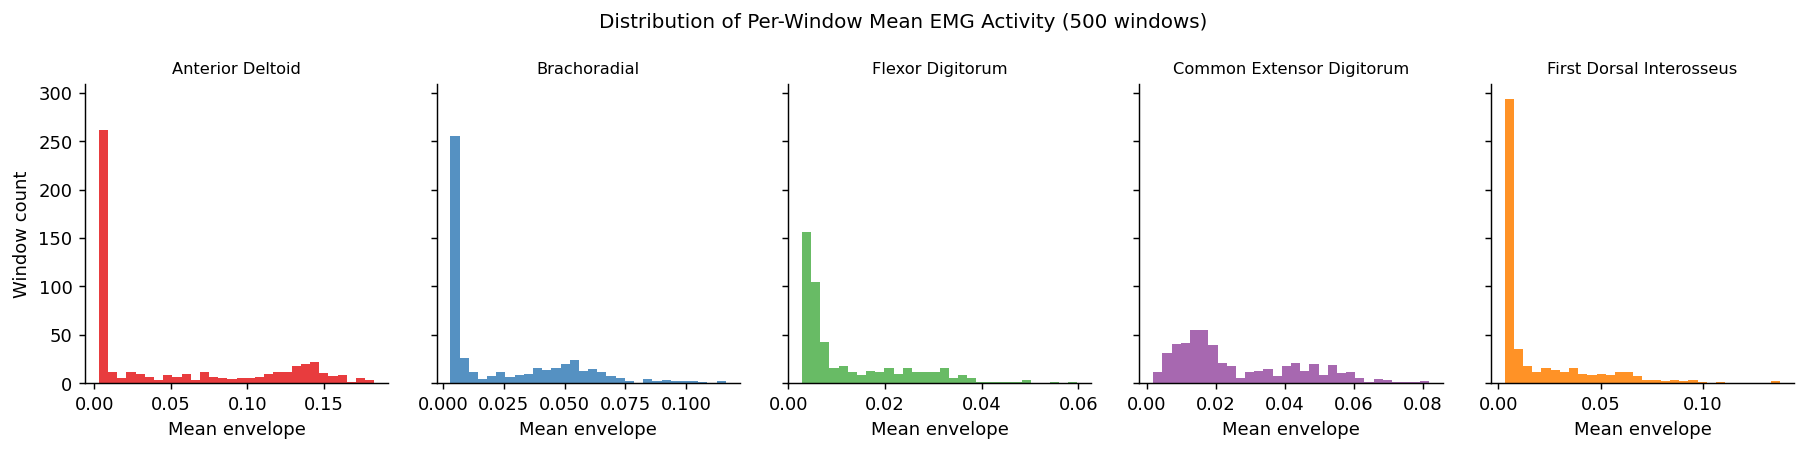

In [30]:
SAMPLE_N = min(500, len(ds))   # sample 500 random windows
rng = np.random.default_rng(42)
idxs = rng.integers(0, len(ds), SAMPLE_N)

emg_means = []
for i in idxs:
    _, _, ew = ds[i]
    emg_means.append(ew.numpy().mean(axis=0))   # (5,)

emg_means = np.stack(emg_means)   # (N, 5)

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5), sharey=True)
for i, (ax, name) in enumerate(zip(axes, raw['emg_names'])):
    ax.hist(emg_means[:, i], bins=30, color=EMG_COLORS[i], edgecolor='none', alpha=0.85)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Mean envelope')

axes[0].set_ylabel('Window count')
fig.suptitle(f'Distribution of Per-Window Mean EMG Activity ({SAMPLE_N} windows)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 7 · Data Integrity Checks

In [31]:
import torch

print('=== Data integrity checks ===')

n_nan = n_inf = 0
sample_idxs = rng.integers(0, len(ds), min(200, len(ds)))

for i in sample_idxs:
    eeg_w, kin_w, emg_w = ds[i]
    for name, t in [('EEG', eeg_w), ('KIN', kin_w), ('EMG', emg_w)]:
        if torch.isnan(t).any():
            n_nan += 1
            print(f'  NaN in window {i} {name}')
        if torch.isinf(t).any():
            n_inf += 1
            print(f'  Inf in window {i} {name}')

print(f'Checked {len(sample_idxs)} windows — NaN: {n_nan}  Inf: {n_inf}')

# Shape checks
eeg_w, kin_w, emg_w = ds[0]
W = cfg['data']['window_size']
assert eeg_w.shape == (W, 32), f'EEG shape mismatch: {eeg_w.shape}'
assert kin_w.shape == (W, 13), f'KIN shape mismatch: {kin_w.shape}'
assert emg_w.shape == (W, 5),  f'EMG shape mismatch: {emg_w.shape}'
print(f'Shape checks passed: EEG {tuple(eeg_w.shape)}  KIN {tuple(kin_w.shape)}  EMG {tuple(emg_w.shape)}')
print('All checks PASSED.')

=== Data integrity checks ===
Checked 200 windows — NaN: 0  Inf: 0
Shape checks passed: EEG (500, 32)  KIN (500, 13)  EMG (500, 5)
All checks PASSED.


---
## Summary

| Stage | Input → Output | Key parameters |
|---|---|---|
| **Load HS** | `.mat` → `{eeg,emg,kin}` dicts | `load_participant()` |
| **EEG preprocess** | (T,32) raw → (T,32) delta | BP 0.1–40 → notch 50 → ASR → CAR → delta 0.1–2 |
| **EMG preprocess** | (T,5) @ 4kHz → (T/8,5) @ 500Hz | BP 30–300 → rectify → LP 10 → decimate ×8 |
| **k_t extraction** | (T,36) raw → (T,13) state | wrist/index/thumb/d_grip/F_L/F_G/ρ_GL |
| **Velocity** | (T,13) → (T,26) | `sg` or `bw` method |
| **CCA alignment** | (T,32) EEG → (T,16) canonical | fit on train split |
| **Dataset windows** | series → (500,32),(500,13),(500,5) | window=500, stride=50 |
